# 01-01 - Checking Your Environment

This is the first notebook of the course and it has exactly one job, showing that the software on your machine works. We explain almost nothing here, because there is nothing yet to explain. We press one button, we watch Princeton appear, and we read what the machine tells us. Everything we run today is taken apart properly in 01-02 and 01-03. If the map appears, you are ready for the precept. If it does not, we would much rather know that now than at five to three in E225.

## How to run this notebook

A notebook is a stack of boxes called **cells**. Some cells hold text, like this one. Some hold Python code, like the grey box below. You run a code cell by clicking it and pressing `Shift+Enter`, and whatever it produces appears directly underneath it.

Today we do not run cells one at a time. We run the whole notebook at once. Find the button labelled **Run All** in the toolbar at the top of this window and click it.

If a panel appears asking which Python environment to use, choose the entry marked *Recommended*, whose path is `/opt/venv/bin/python`. It is named after the course, `urban-ai`. That environment is the one inside the course container, and it is the only one that has the libraries we need. Anything reading `/usr/local/bin/python` is the wrong choice.

The thing you just chose is called a **kernel**, i.e. the Python process that actually does the work. The notebook is only the paper it writes on. Note that this question is asked once per notebook per session, so seeing it again tomorrow is normal and not a sign that something broke.

Click Run All now, then come back here and read on while it works:
The cell below imports every package that any notebook in this course uses, not just the ones needed here. That is deliberate. An environment check that only tests part of the environment can tell you everything is fine and then let the next notebook fail, which is exactly what a check exists to prevent.


In [4]:
import platform
import sys

import contextily
import folium
import geopandas as gpd
import mapclassify
import matplotlib
import numpy
import osmnx
import pandas
import pyogrio
import rasterio
import rioxarray
import seaborn
import shapely
import sklearn
import xarray

print(f"python      {sys.version.split()[0]} on {platform.machine()}")
print(f"geopandas   {gpd.__version__}")
print(f"pyogrio     {pyogrio.__version__}")
print(f"pandas      {pandas.__version__}")
print(f"numpy       {numpy.__version__}")
print(f"osmnx       {osmnx.__version__}")
print(f"folium      {folium.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"seaborn     {seaborn.__version__}")
print(f"shapely     {shapely.__version__}")
print(f"contextily  {contextily.__version__}")
print(f"rasterio    {rasterio.__version__}")
print(f"rioxarray   {rioxarray.__version__}")
print(f"xarray      {xarray.__version__}")
print(f"sklearn     {sklearn.__version__}")


python      3.12.13 on arm64
geopandas   1.1.4
pyogrio     0.13.0
pandas      3.0.5
numpy       2.5.2
osmnx       2.1.1
folium      0.20.0
matplotlib  3.11.1
seaborn     0.13.2
shapely     2.1.2
contextily  1.7.1
rasterio    1.5.1
rioxarray   0.23.0
xarray      2026.7.0
sklearn     1.9.0


We can see a list of lines. The first reports the version of Python, which should begin with 3.12, followed by the architecture of your machine: `arm64` on an Apple laptop, `x86_64` on most Windows machines and in a Codespace. Both are fine, and it is worth knowing which you have, because it explains why your neighbour's download was a different size from yours.

The lines below it are the versions of the libraries this course leans on, every one that any notebook in the course imports. Note that the last digit of each may differ from the screenshots in the setup guide, and that is fine. What matters is that the whole list appeared and that none of it was a red block of text containing the words `ModuleNotFoundError`. If that is what you got instead, skip to the last section of this notebook.

## Does it actually work

Version numbers are reassuring but they are not a map. The real test is whether this machine can read a file of geometry off your disk and turn it into a picture. One file, four lines, one town:

Text(0.5, 1.0, 'Princeton, New Jersey')

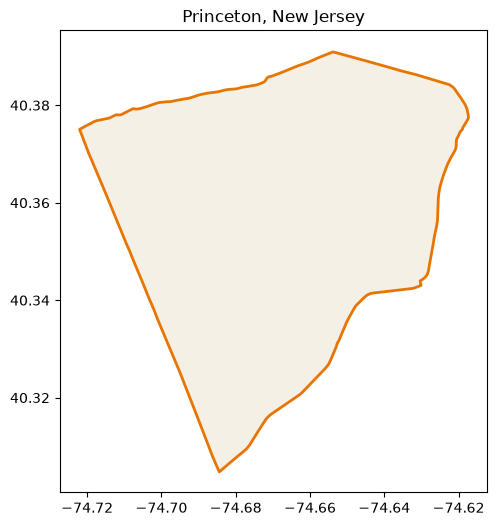

In [5]:
boundary = gpd.read_file("data/princeton_boundary.geojson")

ax = boundary.plot(figsize=(6, 6), color="#f5f0e6", edgecolor="#e77500", linewidth=2)
ax.set_title("Princeton, New Jersey")

We can see a single closed shape, roughly square with a bite taken out of its western side. That is the municipal boundary of Princeton, New Jersey, which is the place this whole course is about.

Read the numbers along the edges of the picture. The horizontal axis runs from about -74.72 to -74.62, and the vertical axis from about 40.30 to 40.39. Those are degrees of longitude and latitude, and the fact that they are visible at all is deliberate. Most maps hide them, and for the rest of today ours will not, because we are going to spend a good deal of 01-03 checking that numbers like these say what we think they say.

Note also that the shape looks slightly squashed compared with the Princeton you would see on a phone. It is, and the reason is interesting rather than a mistake. We come back to it in 01-03.

If a map of Princeton is sitting above this line, your environment is finished and working. One last cell prints the sentence we are all here to see:

In [6]:
print("READY. Your environment works.")

READY. Your environment works.


## While the room catches up

Now that the machine is busy proving itself, here is the one idea that will save you the most confusion over the next few weeks.

The notebook you are looking at is not the same thing as the Python that runs your code. The notebook is paper. The **kernel** is a process sitting behind it that remembers every name you have given to anything. When you ran the cell above, the kernel put the boundary of Princeton into a box labelled `boundary`, and it will remember that box until you close the notebook or restart the kernel.

This has a consequence that catches everybody at least once. The kernel remembers what you *ran*, not what is currently written on the page. If you change a cell and do not re-run it, the kernel keeps the old value. If you run cells out of order, the kernel follows the order you clicked, not the order they appear. The little number in square brackets to the left of each code cell is the honest record: it counts the order things actually ran.

The fix, whenever a notebook starts behaving strangely, is to prove it is honest by starting again from the top. The command is **Restart Kernel and Run All Cells**, and it is worth using whenever you are confused. Notebook 00-01 in the `F00` folder takes this apart with a worked example that deliberately breaks, and it is the most useful thing you can read before the precept.

## If Princeton did not appear

Three things go wrong here, and each has a different look.

**No kernel was chosen.** Nothing runs at all, and a panel keeps asking you to select something. Choose the entry marked *Recommended*, at `/opt/venv/bin/python`.

**`ModuleNotFoundError: No module named 'geopandas'`.** The kernel is running, but it is the wrong Python: your computer's own, rather than the one inside the course container. Check the bottom left corner of the window, which should read `Dev Container: CEE420 Urban AI (FA26)`, and check the kernel picker in the top right of this notebook.

**`FileNotFoundError` or `DriverError`.** Python is fine, but it cannot find `data/princeton_boundary.geojson`. That path is relative, i.e. it means "starting from the folder this notebook lives in". So this error almost always means the notebook has been moved away from the `data` folder that belongs beside it.

Whatever the symptom, the rule for the precept is the same and it is a rule rather than a judgement of you: **try for two minutes, then switch lanes.** Open the repository in a Codespace and carry on with the class from the browser. A Codespace is a full-strength environment running the identical container, not a consolation prize, and several people will be working there all semester. We fix local installations at the clinic, never during the session.

## Further resources

Nothing in this course requires anything below. These are for later, if you want them.

The Jupyter documentation describes the notebook interface in full, including every keyboard shortcut: https://jupyterlab.readthedocs.io/en/stable/user/interface.html. The GeoPandas user guide is the reference for everything we do with spatial tables: https://geopandas.org/en/stable/docs/user_guide.html.

The municipal boundary drawn above is a public record published by NJGIN Open Data, the State of New Jersey's open data portal: https://njogis-newjersey.opendata.arcgis.com.